<a href="https://colab.research.google.com/github/IAMLATI/Predicting-Loan-Default-Loss-Loss-Given-Default-/blob/main/Predicting_Loan_Default_Loss_(Loss_Given_Default).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Predicting Loan Default Loss (Loss Given Default)**
# Business Context **bold text**
When a customer defaults on a loan, the lender does not necessarily lose the full outstanding balance. A portion of the exposure may be recovered through repayments, collateral liquidation, or legal recovery processes. However, the uncertainty around how much is ultimately recovered creates risk in capital planning, pricing, and portfolio management.

# **Problem Statement**
The organization currently faces the challenge of accurately estimating how much money is actually lost once a borrower has defaulted. Without reliable predictions, lenders may:

Hold excess regulatory capital
Under‑ or over‑price credit risk
Make suboptimal recovery and collection decisions

# **Proposed Solution**
This project proposes developing a Loss Given Default (LGD) prediction model that estimates the percentage of a loan exposure that is unrecoverable after a default has occurred. The model will use borrower characteristics, loan terms, credit history, and post‑default payment behavior to generate data‑driven LGD estimates.

# **Business Value**
Regulatory compliance: LGD is a core input in Basel III capital calculations, directly impacting risk‑weighted assets and capital requirements.

Capital efficiency: More accurate LGD estimates enable better alignment between true risk and capital held.

Improved risk management: Helps identify high‑loss segments and prioritize recovery strategies.

Better pricing and portfolio decisions: Supports risk‑based pricing and improves expected loss forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns


In [ ]:
dataset = pd.read_csv("/content/accepted_2007_to_2018Q4.csv")

In [ ]:
dataset.head()

In [255]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906367 entries, 0 to 906366
Columns: 151 entries, id to settlement_term
dtypes: float64(110), object(41)
memory usage: 1.0+ GB


In [256]:
dataset.shape

(906367, 151)

In [257]:
list(dataset.columns)

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [258]:
dataset["loan_status"].value_counts()

,count
loan_status,
Fully Paid,416798
Current,364884
Charged Off,110418
Late (31-120 days),9037
In Grace Period,3465
Late (16-30 days),1737
Default,17


# **CREATING TARGET VARIABLE**

In [259]:
default_status = ["Charged Off", "Default", "Charge"]

In [260]:
df = dataset[dataset['loan_status'].isin(default_status)].copy()

In [261]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
13,66624733,NaN,18000.0,18000.0,18000.0,60 months,19.48,471.70,E,E2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
25,67849662,NaN,4225.0,4225.0,4225.0,36 months,14.85,146.16,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
30,67715283,NaN,16000.0,16000.0,16000.0,36 months,12.88,538.18,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
31,68341789,NaN,24250.0,24250.0,24250.0,60 months,24.24,701.01,F,F3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
33,68415473,NaN,25000.0,25000.0,25000.0,60 months,13.99,581.58,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [262]:
df.shape

(110435, 151)

# **Compute LGD = LGD = 1 - (total_pymnt / funded_amnt)**
Total_pymnt includes: principal repaid + interest + late fees + recoveries
Funded_amnt is the actual amount disbursed to borrower


In [263]:
df['recovery_rate'] = df['total_pymnt'] / df['funded_amnt']
df['LGD'] = 1 - df['recovery_rate']

In [264]:
# Count Anomalies
n_neg = (df['LGD']<0).sum()
n_over = (df['LGD']>1).sum()

print(f" Over_recovery percentage: {n_neg} : ({(n_neg)/(len(df)*100):.2}%)")
print(f" Loss exceeds exposure: {n_over} : ({(n_over)/(len(df)*100):.2}%)")

 Over_recovery percentage: 6183 : (0.00056%)
 Loss exceeds exposure: 0 : (0.0%)


In [265]:
#Clean target
df['LGD_RAW'] = df['LGD'].copy()
df['LGD'] = df['LGD'].clip(0,1)

In [266]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,recovery_rate,LGD,LGD_RAW
13,66624733,NaN,18000.0,18000.0,18000.0,60 months,19.48,471.70,E,E2,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.525152,0.474848,0.474848
25,67849662,NaN,4225.0,4225.0,4225.0,36 months,14.85,146.16,C,C5,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.605650,0.394350,0.394350
30,67715283,NaN,16000.0,16000.0,16000.0,36 months,12.88,538.18,C,C2,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1.087289,0.000000,-0.087289
31,68341789,NaN,24250.0,24250.0,24250.0,60 months,24.24,701.01,F,F3,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.170079,0.829921,0.829921
33,68415473,NaN,25000.0,25000.0,25000.0,60 months,13.99,581.58,C,C4,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.579637,0.420363,0.420363


In [267]:
print(f"MEAN: {(df["LGD"].mean()):.2f})")
print(f"MEDIAN: {(df["LGD"].median()):.2f})")

MEAN: 0.47)
MEDIAN: 0.51)


In [268]:
leakage_cols = [
    # Payment outcomes (used to compute target)
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'out_prncp', 'out_prncp_inv',
    # Post-origination dates and status
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'loan_status',
    # Settlement info (post-default)
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    # Hardship program (post-default intervention)
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date',
    'hardship_end_date', 'payment_plan_start_date', 'hardship_length',
    'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    # Computed columns
    'recovery_rate', 'LGD_raw',
]

# --- IDENTIFIERS: Not predictive ---
id_cols = [
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title',
    'pymnt_plan', 'policy_code',
]

In [269]:
all_drop = [c for c in leakage_cols + id_cols if c in df.columns]

In [270]:
df = df.drop(columns = all_drop)

In [271]:
df.shape

(110435, 107)

In [ ]:
df.shape

(111339, 107)

In [272]:
df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,LGD,LGD_RAW
count,110435.000000,110435.000000,110435.000000,110435.000000,110435.000000,1.104350e+05,110403.000000,110435.000000,110435.000000,110435.000000,...,2260.000000,2260.000000,2199.000000,2260.000000,2260.000000,2260.000000,2260.000000,979.000000,110435.000000,110435.000000
mean,15673.478064,15673.478064,15666.247240,15.290093,462.167329,7.050119e+04,20.873226,0.372319,687.087563,691.087599,...,1.250442,11.188053,63.700591,3.006195,12.211062,0.096460,0.166372,30.763023,0.473393,0.468395
std,8759.145462,8759.145462,8755.557694,4.858321,258.376865,7.200767e+04,11.181646,0.981780,25.663706,25.663930,...,1.658846,6.476883,25.799455,3.311075,8.195928,0.546619,0.622524,23.503448,0.261264,0.271474
min,1000.000000,1000.000000,900.000000,5.310000,30.120000,0.000000e+00,0.000000,0.000000,660.000000,664.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.611756
25%,9150.000000,9150.000000,9125.000000,11.990000,275.340000,4.300000e+04,14.020000,0.000000,670.000000,674.000000,...,0.000000,6.000000,46.050000,1.000000,6.000000,0.000000,0.000000,9.000000,0.266007,0.266007
50%,14400.000000,14400.000000,14400.000000,14.650000,400.240000,6.000000e+04,20.470000,0.000000,680.000000,684.000000,...,1.000000,10.000000,66.700000,2.000000,10.000000,0.000000,0.000000,27.000000,0.506762,0.506762
75%,20700.000000,20700.000000,20675.000000,18.200000,599.570000,8.500000e+04,27.350000,0.000000,700.000000,704.000000,...,2.000000,15.000000,84.050000,4.000000,16.000000,0.000000,0.000000,50.000000,0.683203,0.683203
max,40000.000000,40000.000000,40000.000000,30.990000,1717.630000,9.500000e+06,999.000000,27.000000,845.000000,850.000000,...,13.000000,46.000000,212.600000,33.000000,61.000000,11.000000,11.000000,94.000000,1.000000,1.000000


In [273]:
df.duplicated().sum()

np.int64(11)

In [274]:
df[df['LGD'].isnull()]

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,disbursement_method,LGD,LGD_RAW


In [275]:
df.to_csv("Cleaned_df.csv", index=False)

In [3]:
df = pd.read_csv("/content/Cleaned_df (1).csv")

In [4]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,disbursement_method,LGD,LGD_RAW
0,18000.0,18000.0,18000.0,60 months,19.48,471.70,E,E2,7 years,RENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.474848,0.474848
1,4225.0,4225.0,4225.0,36 months,14.85,146.16,C,C5,5 years,RENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.394350,0.394350
2,16000.0,16000.0,16000.0,36 months,12.88,538.18,C,C2,10+ years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.000000,-0.087289
3,24250.0,24250.0,24250.0,60 months,24.24,701.01,F,F3,4 years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.829921,0.829921
4,25000.0,25000.0,25000.0,60 months,13.99,581.58,C,C4,9 years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.420363,0.420363


In [5]:
features = [c for c in df.columns if c != 'LGD']
cat_feats = [features for features in df.columns if df[features].dtypes=="O"]
numeric_feats = [features for features in df.columns if df[features].dtypes!="O"]

In [9]:
print(f' Catergoical columns : {cat_feats} : number of catergoical columns: {len(cat_feats)}')
print(f' Numberical columns : {numeric_feats} : number of Numberical columns: {len(numeric_feats)}')

 Catergoical columns : ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'verification_status_joint', 'sec_app_earliest_cr_line', 'disbursement_method'] : number of catergoical columns: 16
 Numberical columns : ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_las


---Target Variable Distribution ---


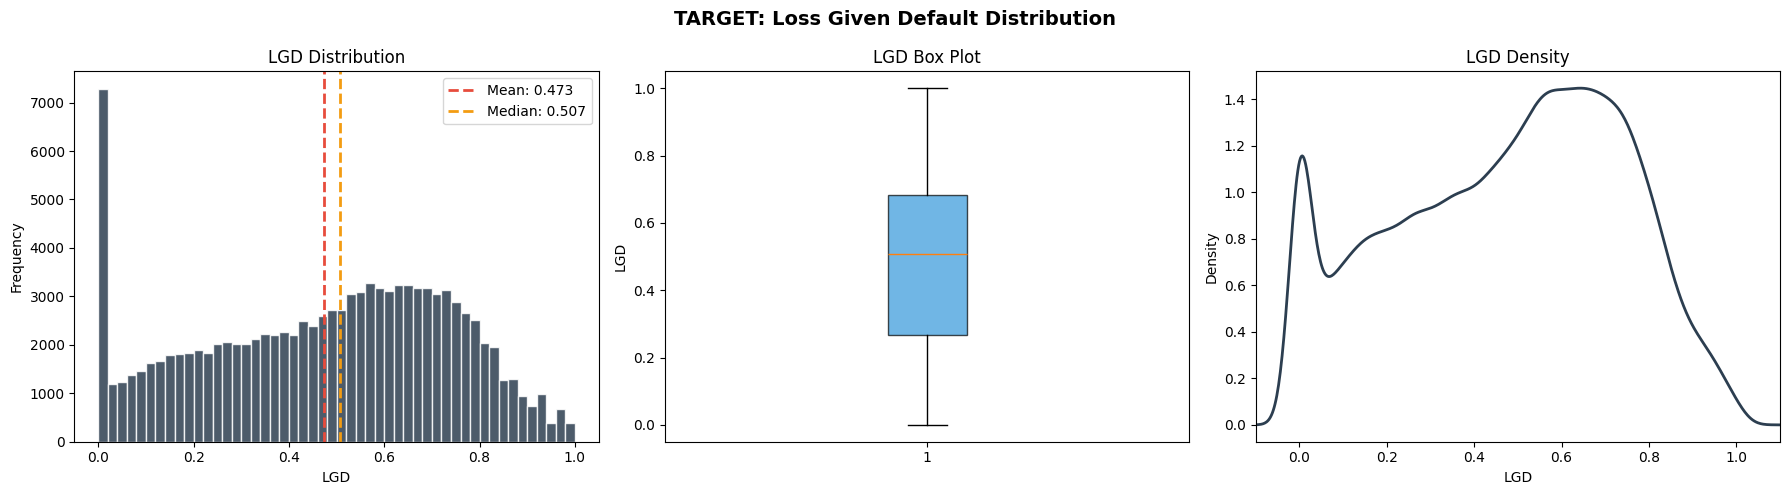

In [13]:
print("\n---Target Variable Distribution ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['LGD'], bins=50, color='#2c3e50', edgecolor='white', alpha=0.85)
axes[0].axvline(df['LGD'].mean(), color='#e74c3c', ls='--', lw=2,
                label=f"Mean: {df['LGD'].mean():.3f}")
axes[0].axvline(df['LGD'].median(), color='#f39c12', ls='--', lw=2,
                label=f"Median: {df['LGD'].median():.3f}")
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Frequency')
axes[0].set_title('LGD Distribution')
axes[0].legend()

axes[1].boxplot(df['LGD'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_ylabel('LGD')
axes[1].set_title('LGD Box Plot')

try:
    df['LGD'].plot.kde(ax=axes[2], color='#2c3e50', lw=2)
except:
    axes[2].hist(df['LGD'], bins=50, density=True, color='#2c3e50', alpha=0.7)
axes[2].set_xlabel('LGD')
axes[2].set_title('LGD Density')
axes[2].set_xlim(-0.1, 1.1)

plt.suptitle('TARGET: Loss Given Default Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_lgd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
